In [2]:
# 单元格1：导入库和加载数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 解决中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

# 加载你预处理好的数据
df = pd.read_csv('../01_data/processed/shopping_trends_processed.csv')
print(f'✓ 数据加载成功，形状: {df.shape}')
print(f'数据列名: {df.columns.tolist()}')

✓ 数据加载成功，形状: (3900, 21)
数据列名: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases', 'Frequency_Encoded', 'Spending_Level']


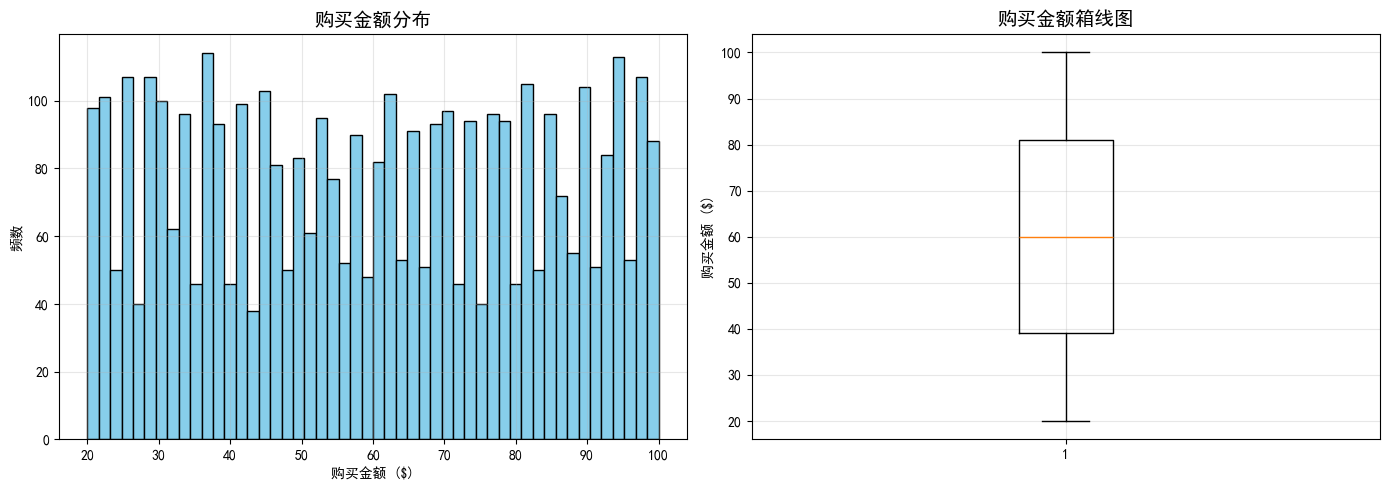

✓ 图表已保存: 04_results/figures/01_购买金额分布.png


In [3]:
# 单元格2：购买金额分布分析
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图
axes[0].hist(df['Purchase Amount (USD)'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('购买金额分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('购买金额 ($)')
axes[0].set_ylabel('频数')
axes[0].grid(True, alpha=0.3)

# 箱线图
axes[1].boxplot(df['Purchase Amount (USD)'])
axes[1].set_title('购买金额箱线图', fontsize=14, fontweight='bold')
axes[1].set_ylabel('购买金额 ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../04_results/figures/01_购买金额分布.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/01_购买金额分布.png")

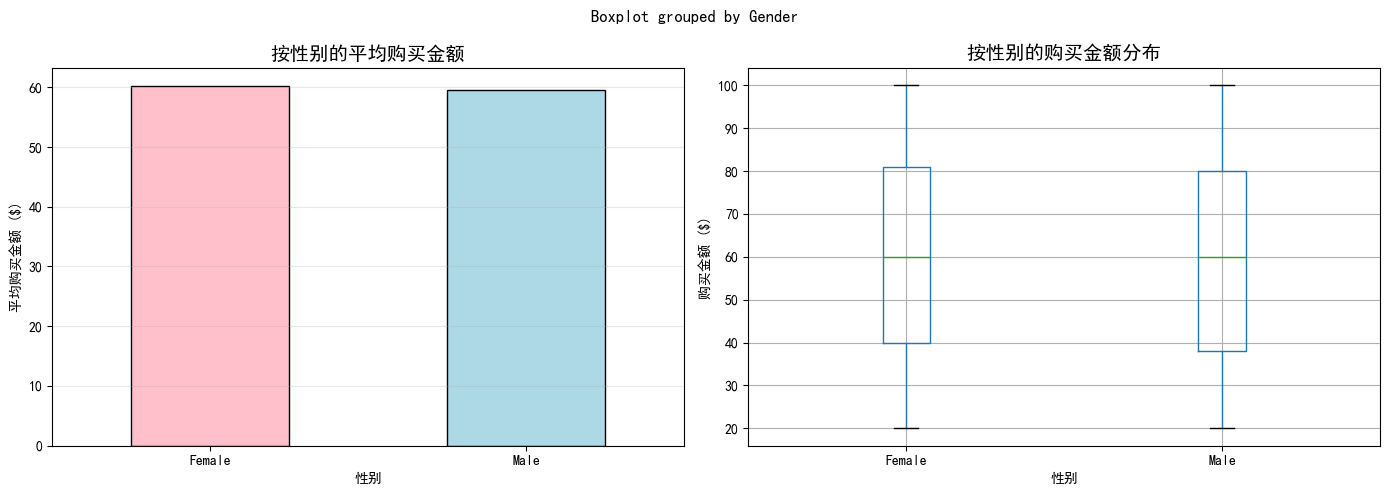

✓ 图表已保存: 04_results/figures/02_按性别的购买分析.png


In [4]:
# 单元格3：按性别分析购买金额
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按性别的平均购买金额
gender_stats = df.groupby('Gender')['Purchase Amount (USD)'].agg(['mean', 'count'])
gender_stats['mean'].plot(kind='bar', ax=axes[0], color=['pink', 'lightblue'], edgecolor='black')
axes[0].set_title('按性别的平均购买金额', fontsize=14, fontweight='bold')
axes[0].set_xlabel('性别')
axes[0].set_ylabel('平均购买金额 ($)')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# 按性别的购买金额分布（箱线图）
df.boxplot(column='Purchase Amount (USD)', by='Gender', ax=axes[1])
axes[1].set_title('按性别的购买金额分布', fontsize=14, fontweight='bold')
axes[1].set_xlabel('性别')
axes[1].set_ylabel('购买金额 ($)')
plt.sca(axes[1])
plt.xticks([1, 2], ['Female', 'Male'])

plt.tight_layout()
plt.savefig('../04_results/figures/02_按性别的购买分析.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/02_按性别的购买分析.png")

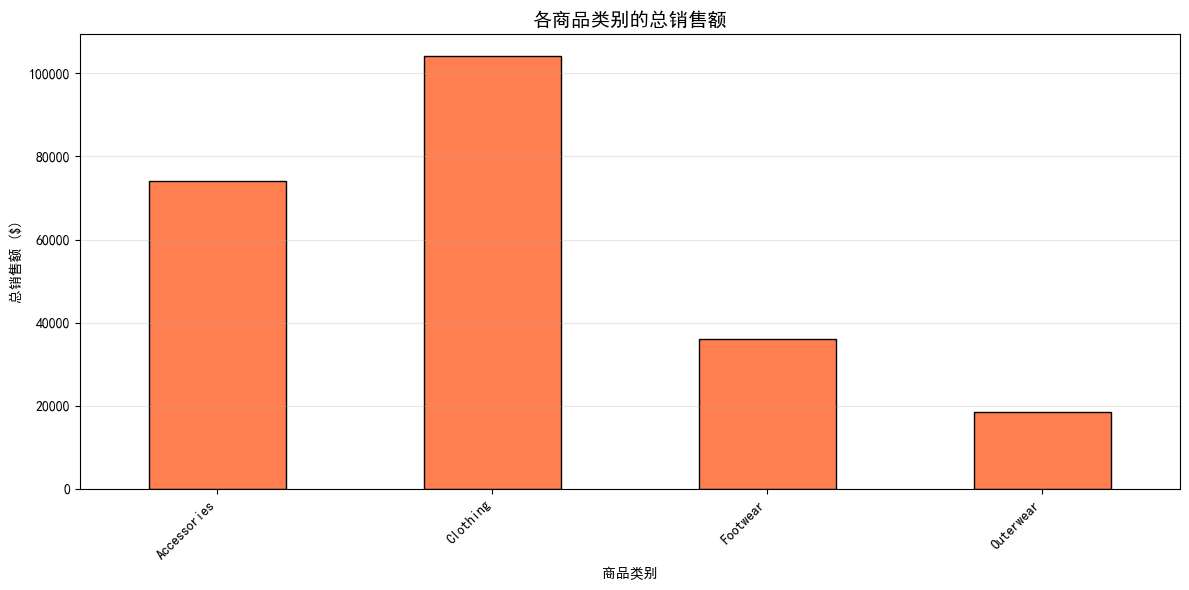

✓ 图表已保存: 04_results/figures/03_按类别的销售额.png


In [5]:
# 单元格4：按商品类别分析
fig, ax = plt.subplots(figsize=(12, 6))

category_stats = df.groupby('Category')['Purchase Amount (USD)'].agg(['sum', 'mean', 'count'])
category_stats['sum'].plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('各商品类别的总销售额', fontsize=14, fontweight='bold')
ax.set_xlabel('商品类别')
ax.set_ylabel('总销售额 ($)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../04_results/figures/03_按类别的销售额.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/03_按类别的销售额.png")

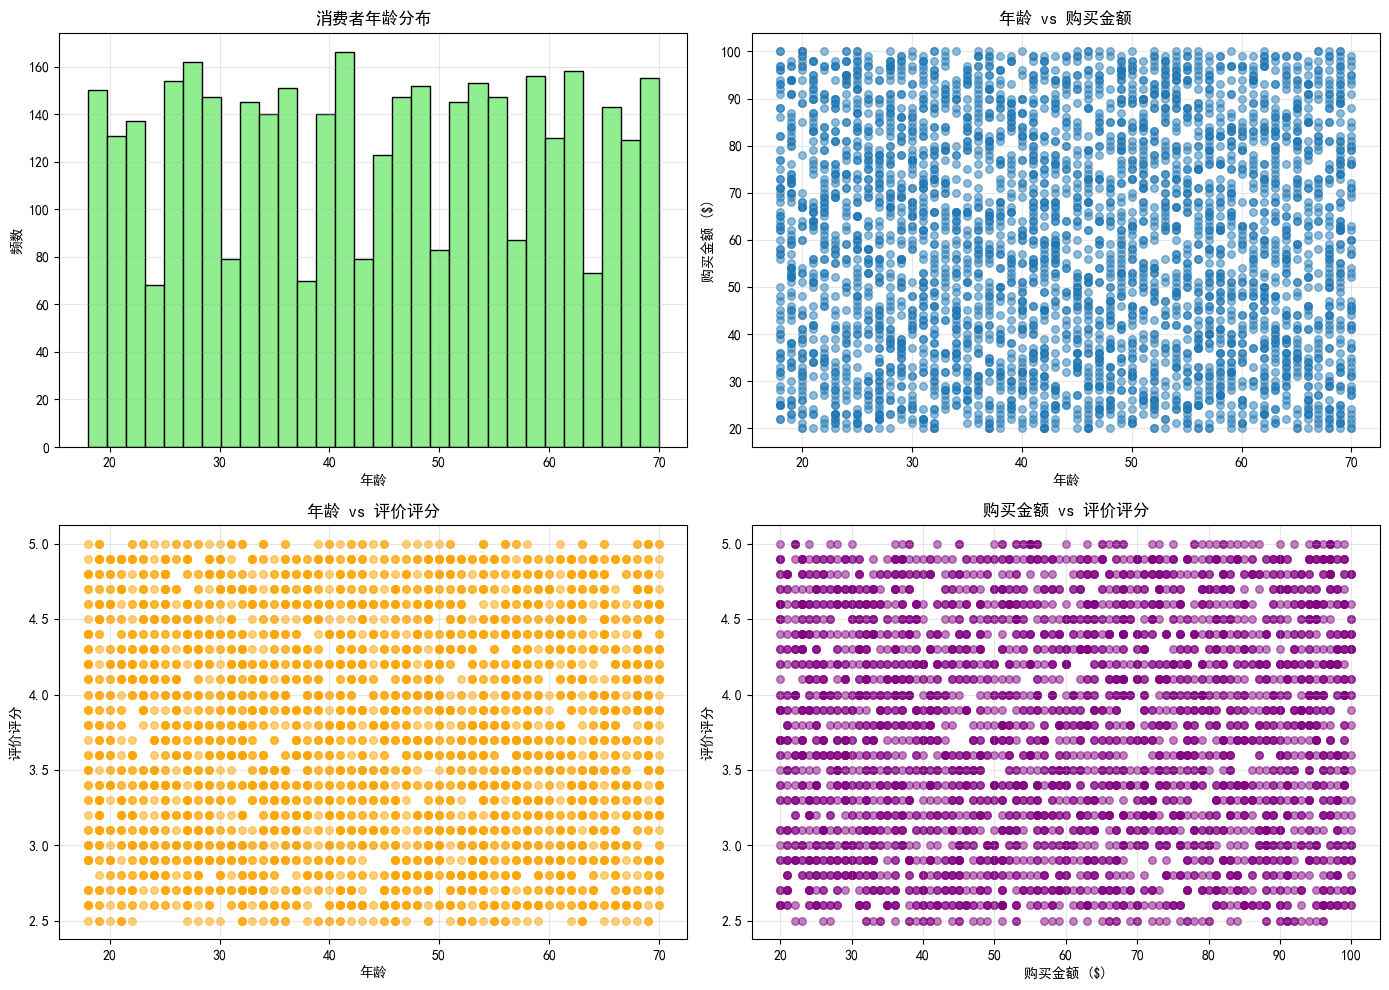

✓ 图表已保存: 04_results/figures/04_年龄相关分析.png


In [6]:
# 单元格5：按年龄分析购买行为
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 年龄分布
axes[0, 0].hist(df['Age'], bins=30, edgecolor='black', color='lightgreen')
axes[0, 0].set_title('消费者年龄分布', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('年龄')
axes[0, 0].set_ylabel('频数')
axes[0, 0].grid(True, alpha=0.3)

# 年龄与购买金额的关系
axes[0, 1].scatter(df['Age'], df['Purchase Amount (USD)'], alpha=0.5, s=30)
axes[0, 1].set_title('年龄 vs 购买金额', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('年龄')
axes[0, 1].set_ylabel('购买金额 ($)')
axes[0, 1].grid(True, alpha=0.3)

# 年龄与评价评分的关系
axes[1, 0].scatter(df['Age'], df['Review Rating'], alpha=0.5, s=30, color='orange')
axes[1, 0].set_title('年龄 vs 评价评分', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('年龄')
axes[1, 0].set_ylabel('评价评分')
axes[1, 0].grid(True, alpha=0.3)

# 购买金额与评价评分的关系
axes[1, 1].scatter(df['Purchase Amount (USD)'], df['Review Rating'], alpha=0.5, s=30, color='purple')
axes[1, 1].set_title('购买金额 vs 评价评分', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('购买金额 ($)')
axes[1, 1].set_ylabel('评价评分')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../04_results/figures/04_年龄相关分析.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/04_年龄相关分析.png")

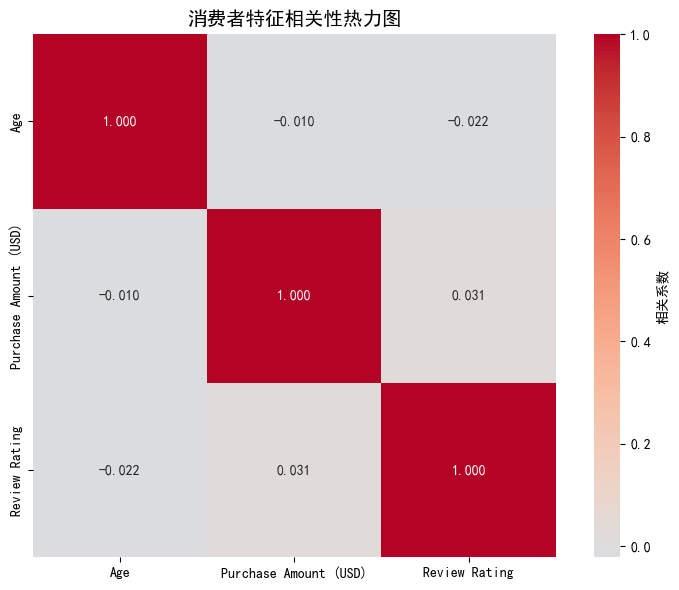

✓ 图表已保存: 04_results/figures/05_相关性热力图.png


In [7]:
# 单元格6：相关性分析
# 选择数值列进行相关性分析
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating']
correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.3f', 
    cmap='coolwarm',
    center=0, 
    square=True, 
    ax=ax, 
    cbar_kws={'label': '相关系数'}
)
ax.set_title('消费者特征相关性热力图', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../04_results/figures/05_相关性热力图.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/05_相关性热力图.png")

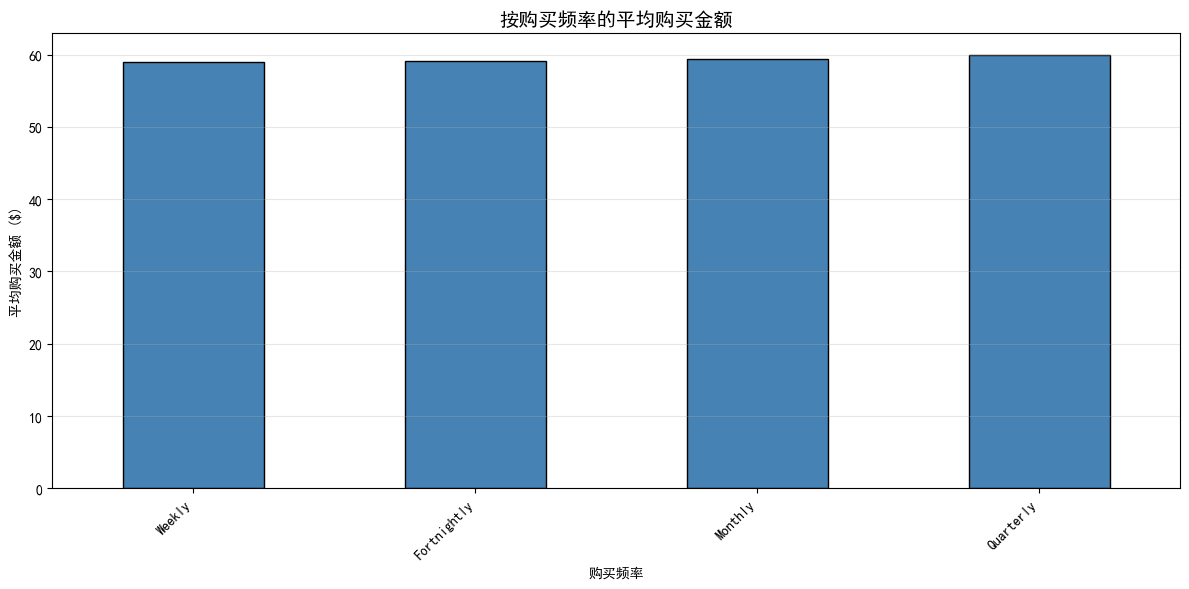

✓ 图表已保存: 04_results/figures/06_按频率的购买分析.png


In [8]:
# 单元格7：按购买频率分析
fig, ax = plt.subplots(figsize=(12, 6))

frequency_order = ['Weekly', 'Fortnightly', 'Monthly', 'Quarterly']
frequency_stats = df.groupby('Frequency of Purchases')['Purchase Amount (USD)'].mean().reindex(frequency_order)
frequency_stats.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('按购买频率的平均购买金额', fontsize=14, fontweight='bold')
ax.set_xlabel('购买频率')
ax.set_ylabel('平均购买金额 ($)')
ax.set_xticklabels(frequency_order, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../04_results/figures/06_按频率的购买分析.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/06_按频率的购买分析.png")

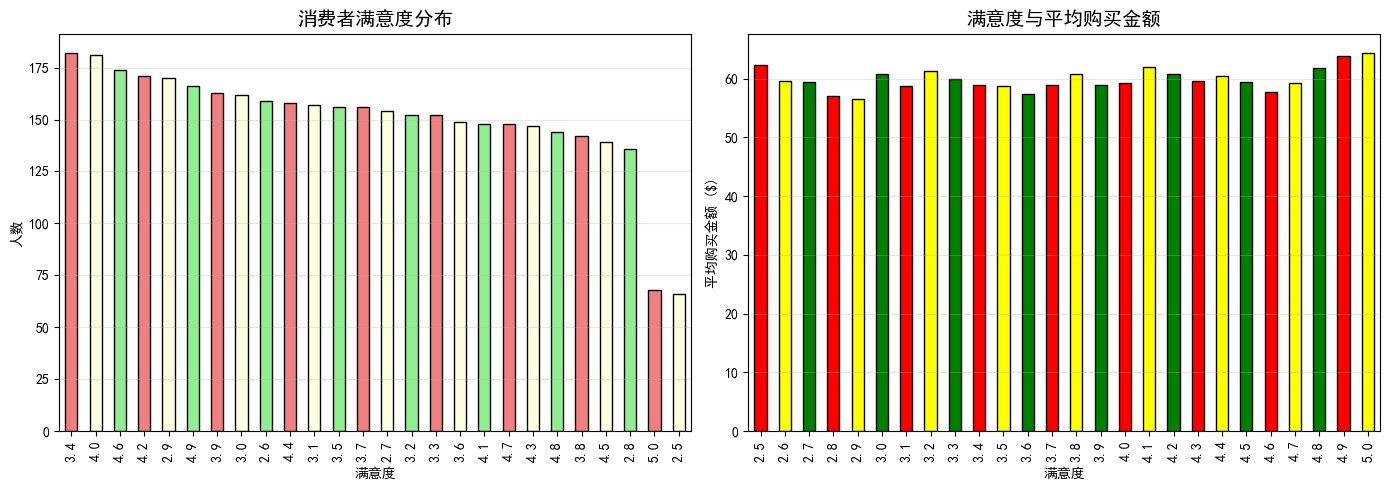

✓ 图表已保存: 04_results/figures/07_满意度分析.png


In [9]:
# 单元格8：满意度分析
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 满意度分布
satisfaction_counts = df['Review Rating'].value_counts()
satisfaction_counts.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightyellow', 'lightgreen'], edgecolor='black')
axes[0].set_title('消费者满意度分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('满意度')
axes[0].set_ylabel('人数')
axes[0].grid(True, alpha=0.3, axis='y')

# 满意度与购买金额的关系
satisfaction_purchase = df.groupby('Review Rating')['Purchase Amount (USD)'].mean()
satisfaction_purchase.plot(kind='bar', ax=axes[1], color=['red', 'yellow', 'green'], edgecolor='black')
axes[1].set_title('满意度与平均购买金额', fontsize=14, fontweight='bold')
axes[1].set_xlabel('满意度')
axes[1].set_ylabel('平均购买金额 ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../04_results/figures/07_满意度分析.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图表已保存: 04_results/figures/07_满意度分析.png")

In [10]:
# 单元格9：生成统计汇总表
summary_stats = {
    '指标': [
        '消费者总数',
        '平均购买金额',
        '购买金额中位数',
        '购买金额标准差',
        '平均年龄',
        '平均评价评分',
        '男性比例',
        '使用促销码比例'
    ],
    '数值': [
        len(df),
        f"${df['Purchase Amount (USD)'].mean():.2f}",
        f"${df['Purchase Amount (USD)'].median():.2f}",
        f"${df['Purchase Amount (USD)'].std():.2f}",
        f"{df['Age'].mean():.1f}岁",
        f"{df['Review Rating'].mean():.2f}",
        f"{(df['Gender']=='Male').sum()/len(df)*100:.1f}%",
        f"{(df['Promo Code Used']=='Yes').sum()/len(df)*100:.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n统计汇总:")
print(summary_df.to_string(index=False))

summary_df.to_csv('../04_results/tables/01_统计汇总.csv', index=False)
print("\n✓ 统计汇总已保存: 04_results/tables/01_统计汇总.csv")


统计汇总:
     指标     数值
  消费者总数   3900
 平均购买金额 $59.76
购买金额中位数 $60.00
购买金额标准差 $23.69
   平均年龄  44.1岁
 平均评价评分   3.75
   男性比例  68.0%
使用促销码比例  43.0%

✓ 统计汇总已保存: 04_results/tables/01_统计汇总.csv
